<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/process_automation_api_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Process Automation API Demo

This notebook demonstrates the main capabilities from the NeqSim Process Automation API documentation: string addresses, variable discovery, unit conversion, convenience delegates, safe accessors, structured JSON diagnostics, batch setpoint updates, run feedback, `evaluate(...)`, utilization snapshots, adjustable parameters, and multi-area `ProcessModel` addresses.

The theme is agentic process engineering: a Python script or AI agent can discover a flowsheet, decide what it is allowed to change, apply setpoints, run the model, and read back results without navigating Java objects directly.


## Setup

Install and import NeqSim classes used by the demo.


In [6]:
# Install NeqSim when running in a fresh Colab session.
try:
    import neqsim
except ImportError:
    %pip install neqsim

import json
import pandas as pd
import matplotlib.pyplot as plt
import jpype
try:
    from neqsim import jneqsim
except ImportError:
    from neqsim import jNeqSim as jneqsim
from neqsim.thermo import TPflash

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ProcessModel = jneqsim.process.processmodel.ProcessModel

ArrayList = jpype.JClass("java.util.ArrayList")
LinkedHashMap = jpype.JClass("java.util.LinkedHashMap")


def java_list(items):
    values = ArrayList()
    for item in items:
        values.add(item)
    return values


def java_map(mapping):
    values = LinkedHashMap()
    for key, value in mapping.items():
        values.put(key, float(value))
    return values


def as_json(value):
    return json.loads(str(value))


def show_json(value, max_chars=1200):
    text = json.dumps(as_json(value), indent=2)
    print(text[:max_chars] + ("\n..." if len(text) > max_chars else ""))

## Build a Small Process

The flowsheet contains a feed stream, a heater/cooler, a separator, and a compressor.


In [7]:
def make_gas(temperature_c=25.0, pressure_bara=60.0):
    fluid = SystemSrkEos(273.15 + temperature_c, pressure_bara)
    fluid.addComponent("nitrogen", 0.01)
    fluid.addComponent("CO2", 0.02)
    fluid.addComponent("methane", 0.86)
    fluid.addComponent("ethane", 0.07)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("n-butane", 0.01)
    fluid.setMixingRule("classic")
    TPflash(fluid)
    fluid.initProperties()
    return fluid

fluid = make_gas()
feed = Stream("Feed gas", fluid)
feed.setFlowRate(10000.0, "kg/hr")

Heater = jneqsim.process.equipment.heatexchanger.Heater
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor

cooler = Heater("Gas cooler", feed)
cooler.setOutTemperature(273.15 + 15.0)
separator = Separator("Inlet separator", cooler.getOutStream())
compressor = Compressor("Export compressor", separator.getGasOutStream())
compressor.setOutletPressure(90.0)
compressor.getMechanicalDesign().setMaxDesignPower(500.0)

process = ProcessSystem()
for unit in [feed, cooler, separator, compressor]:
    process.add(unit)
process.run()

auto = process.getAutomation()
print("Solved units:", list(auto.getUnitList()))
print("Initial compressor power: %.1f kW" % auto.getVariableValue("Export compressor.power", "kW"))

Solved units: ['Feed gas', 'Gas cooler', 'Inlet separator', 'Export compressor']
Initial compressor power: 127.6 kW


## Discover Units and Variables

The automation facade exposes units and variables without navigating Java class internals.


In [8]:
unit_rows = []
variable_rows = []

for unit_name in list(auto.getUnitList()):
    unit_rows.append(
        {
            "unit": unit_name,
            "equipment_type": auto.getEquipmentType(unit_name),
        }
    )
    for variable in auto.getVariableList(unit_name):
        variable_rows.append(
            {
                "unit": unit_name,
                "address": variable.getAddress(),
                "name": variable.getName(),
                "type": str(variable.getType()),
                "default_unit": variable.getDefaultUnit(),
                "unit_family": variable.getUnitFamily(),
                "description": variable.getDescription(),
            }
        )

units_df = pd.DataFrame(unit_rows)
variables_df = pd.DataFrame(variable_rows)

print("Automation facade is multi-area:", bool(auto.isMultiArea()))
display(units_df)
display(variables_df.head(20))
print("Writable inputs:")
display(variables_df[variables_df["type"].str.contains("INPUT")][["address", "default_unit", "description"]])

Automation facade is multi-area: False


,unit,equipment_type
0,"(F, e, e, d, , g, a, s)","(S, t, r, e, a, m)"
1,"(G, a, s, , c, o, o, l, e, r)","(H, e, a, t, e, r)"
2,"(I, n, l, e, t, , s, e, p, a, r, a, t, o, r)","(S, e, p, a, r, a, t, o, r)"
3,"(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, ...","(C, o, m, p, r, e, s, s, o, r)"


,unit,address,name,type,default_unit,unit_family,description
0,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., t, e, m, p, e, r, ...","(t, e, m, p, e, r, a, t, u, r, e)",OUTPUT,(K),"(t, e, m, p, e, r, a, t, u, r, e)","(E, q, u, i, p, m, e, n, t, , t, e, m, p, e, ..."
1,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., p, r, e, s, s, u, ...","(p, r, e, s, s, u, r, e)",OUTPUT,"(b, a, r, a)","(p, r, e, s, s, u, r, e)","(E, q, u, i, p, m, e, n, t, , p, r, e, s, s, ..."
2,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., t, e, m, p, e, r, ...","(t, e, m, p, e, r, a, t, u, r, e)",INPUT,(K),"(t, e, m, p, e, r, a, t, u, r, e)","(S, t, r, e, a, m, , t, e, m, p, e, r, a, t, ..."
3,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., p, r, e, s, s, u, ...","(p, r, e, s, s, u, r, e)",INPUT,"(b, a, r, a)","(p, r, e, s, s, u, r, e)","(S, t, r, e, a, m, , p, r, e, s, s, u, r, e)"
4,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., f, l, o, w, R, a, ...","(f, l, o, w, R, a, t, e)",INPUT,"(k, g, /, h, r)","(f, l, o, w)","(S, t, r, e, a, m, , m, a, s, s, , f, l, o, ..."
5,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., d, e, n, s, i, t, y)","(d, e, n, s, i, t, y)",OUTPUT,"(k, g, /, m, 3)","(d, e, n, s, i, t, y)","(S, t, r, e, a, m, , d, e, n, s, i, t, y)"
6,"(F, e, e, d, , g, a, s)","(F, e, e, d, , g, a, s, ., m, o, l, a, r, M, ...","(m, o, l, a, r, M, a, s, s)",OUTPUT,"(k, g, /, m, o, l)","(o, t, h, e, r)","(S, t, r, e, a, m, , m, o, l, a, r, , m, a, ..."
7,"(G, a, s, , c, o, o, l, e, r)","(G, a, s, , c, o, o, l, e, r, ., t, e, m, p, ...","(t, e, m, p, e, r, a, t, u, r, e)",OUTPUT,(K),"(t, e, m, p, e, r, a, t, u, r, e)","(E, q, u, i, p, m, e, n, t, , t, e, m, p, e, ..."
8,"(G, a, s, , c, o, o, l, e, r)","(G, a, s, , c, o, o, l, e, r, ., p, r, e, s, ...","(p, r, e, s, s, u, r, e)",OUTPUT,"(b, a, r, a)","(p, r, e, s, s, u, r, e)","(E, q, u, i, p, m, e, n, t, , p, r, e, s, s, ..."
9,"(G, a, s, , c, o, o, l, e, r)","(G, a, s, , c, o, o, l, e, r, ., o, u, t, l, ...","(o, u, t, l, e, t, T, e, m, p, e, r, a, t, u, ...",INPUT,(C),"(t, e, m, p, e, r, a, t, u, r, e)","(H, e, a, t, e, r, , o, u, t, l, e, t, , t, ..."


Writable inputs:


,address,default_unit,description
2,"(F, e, e, d, , g, a, s, ., t, e, m, p, e, r, ...",(K),"(S, t, r, e, a, m, , t, e, m, p, e, r, a, t, ..."
3,"(F, e, e, d, , g, a, s, ., p, r, e, s, s, u, ...","(b, a, r, a)","(S, t, r, e, a, m, , p, r, e, s, s, u, r, e)"
4,"(F, e, e, d, , g, a, s, ., f, l, o, w, R, a, ...","(k, g, /, h, r)","(S, t, r, e, a, m, , m, a, s, s, , f, l, o, ..."
9,"(G, a, s, , c, o, o, l, e, r, ., o, u, t, l, ...",(C),"(H, e, a, t, e, r, , o, u, t, l, e, t, , t, ..."
30,"(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, ...","(b, a, r, a)","(C, o, m, p, r, e, s, s, o, r, , o, u, t, l, ..."
31,"(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, ...",(),"(P, o, l, y, t, r, o, p, i, c, , e, f, f, i, ..."
34,"(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, ...","(r, p, m)","(C, o, m, p, r, e, s, s, o, r, , s, p, e, e, d)"


## Read Values, Convert Units, and Use Convenience Delegates

Addresses use `unit.property` for equipment variables and `unit.port.property` for connected streams. The automation facade handles unit conversion, and `ProcessSystem` exposes convenience delegates for the same operations.

In [9]:
unit_conversion = pd.DataFrame(
    [
        {
            "quantity": "separator gas outlet temperature",
            "address": "Inlet separator.gasOutStream.temperature",
            "K": auto.getVariableValue("Inlet separator.gasOutStream.temperature", "K"),
            "C": auto.getVariableValue("Inlet separator.gasOutStream.temperature", "C"),
            "F": auto.getVariableValue("Inlet separator.gasOutStream.temperature", "F"),
        },
        {
            "quantity": "compressor outlet pressure",
            "address": "Export compressor.outletStream.pressure",
            "bara": auto.getVariableValue("Export compressor.outletStream.pressure", "bara"),
            "barg": auto.getVariableValue("Export compressor.outletStream.pressure", "barg"),
            "psi": auto.getVariableValue("Export compressor.outletStream.pressure", "psi"),
        },
    ]
)

delegate_power = process.getVariableValue("Export compressor.power", "kW")
automation_power = auto.getVariableValue("Export compressor.power", "kW")

print("ProcessSystem delegate equals automation read:", abs(delegate_power - automation_power) < 1.0e-9)
display(unit_conversion)

ProcessSystem delegate equals automation read: True


,quantity,address,K,C,F,bara,barg,psi
0,separator gas outlet temperature,Inlet separator.gasOutStream.temperature,288.15,15.0,59.0,NaN,NaN,NaN
1,compressor outlet pressure,Export compressor.outletStream.pressure,NaN,NaN,NaN,90.0,88.98675,1305.33964


## Structured Snapshots

Snapshots and topology are JSON strings that can be stored, compared, or used by agents.


In [10]:
snapshot = as_json(auto.snapshot("*"))
topology = as_json(auto.getTopology())
neighbors = as_json(auto.getNeighbors("Gas cooler"))

print("Snapshot schema:", snapshot.get("schemaVersion"))
print("Units in snapshot:", [unit["name"] for unit in snapshot.get("units", [])])
print("Topology keys:", list(topology.keys()))
print("Gas cooler downstream neighbors:", neighbors.get("downstream"))

Snapshot schema: 1.0
Units in snapshot: ['Feed gas', 'Gas cooler', 'Inlet separator', 'Export compressor']
Topology keys: ['schemaVersion', 'equipment', 'connections']
Gas cooler downstream neighbors: ['Inlet separator']


## Batch Reads, Batch Writes, and Dirty-Aware Runs

`getValues(...)` and `setValues(...)` are useful when an agent wants to apply a candidate case in one step. The dirty flag avoids rerunning a process when no setpoint has changed.

In [11]:
readbacks = java_list([
    "Feed gas.pressure",
    "Gas cooler.outletTemperature",
    "Export compressor.outletPressure",
    "Export compressor.power",
])
base_values = dict(auto.getValues(readbacks, "bara"))

changed_count = auto.setValues(
    java_map(
        {
            "Feed gas.pressure": 62.0,
            "Export compressor.outletPressure": 100.0,
        }
    ),
    "bara",
    True,
)
updated_values = dict(auto.getValues(readbacks, "bara"))

print("Number of setpoints accepted:", changed_count)
print("Dirty after run:", bool(auto.isDirty()))
display(pd.DataFrame([base_values, updated_values], index=["before", "after"]))

Number of setpoints accepted: 2
Dirty after run: False


,"(F, e, e, d, , g, a, s, ., p, r, e, s, s, u, r, e)","(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, o, r, ., o, u, t, l, e, t, P, r, e, s, s, u, r, e)","(E, x, p, o, r, t, , c, o, m, p, r, e, s, s, o, r, ., p, o, w, e, r)"
before,60.0,90.0,127577.198562
after,62.0,100.0,151415.782134


## Safe Accessors for LLM-Generated Addresses

LLMs often produce approximate labels: wrong capitalization, missing dots, or a guessed unit name. The safe accessors return JSON diagnostics instead of derailing the run with a Java exception. An agent can feed the suggestions back into its next attempt.

In [12]:
bad_read = as_json(auto.getVariableValueSafe("export compresor pwer", "kW"))
case_tolerant_read = as_json(auto.getVariableValueSafe("export compressor.power", "kW"))
read_only_attempt = None

try:
    auto.setVariableValue("Export compressor.power", 100.0, "kW")
except Exception as exc:
    read_only_attempt = str(exc)

display(
    pd.DataFrame(
        [
            {
                "attempt": "misspelled free-text address",
                "status_or_category": bad_read.get("status", bad_read.get("category")),
                "suggestions": bad_read.get("suggestions"),
            },
            {
                "attempt": "case-insensitive dotted address",
                "status_or_category": case_tolerant_read.get("status", case_tolerant_read.get("category")),
                "value_kW": case_tolerant_read.get("value"),
            },
            {
                "attempt": "write to read-only power output",
                "status_or_category": "exception from strict setter",
                "suggestions": read_only_attempt[:120],
            },
        ]
    )
)

print("Diagnostics learning report after safe-access attempts:")
show_json(auto.getDiagnostics().getLearningReport(), max_chars=1200)

,attempt,status_or_category,suggestions,value_kW
0,misspelled free-text address,UNIT_NOT_FOUND,"[Export compressor, Gas cooler, Inlet separato...",NaN
1,case-insensitive dotted address,success,NaN,151.415782
2,write to read-only power output,exception from strict setter,java.lang.IllegalArgumentException: Cannot set...,NaN


Diagnostics learning report after safe-access attempts:
{
  "totalOperations": 4,
  "successRate": 0.25,
  "errorCategories": {
    "INVALID_ADDRESS_FORMAT": 2,
    "UNIT_NOT_FOUND": 1
  },
  "learnedCorrections": {},
  "recentFailures": [
    {
      "operation": "get",
      "address": "export compresor pwer",
      "errorCategory": "UNIT_NOT_FOUND"
    },
    {
      "operation": "get",
      "address": "Gas cooler.outletTemperature",
      "errorCategory": "INVALID_ADDRESS_FORMAT"
    },
    {
      "operation": "get",
      "address": "Gas cooler.outletTemperature",
      "errorCategory": "INVALID_ADDRESS_FORMAT"
    }
  ],
  "recommendations": []
}


## Machine-Readable Context for an Agent

`describe()`, `getStructured(...)`, and `getAdjustableParametersJson()` turn the live process into compact JSON. That JSON can be passed to an LLM or optimizer as the available action space and observation context.

In [13]:
manifest = as_json(auto.describe())
composition = as_json(auto.getStructured("Inlet separator.gasOutStream.composition"))
adjustables = as_json(auto.getAdjustableParametersJson())

action_space = pd.DataFrame(adjustables.get("parameters", []))

print("Manifest contains %d units and %d adjustable parameters." % (len(manifest.get("units", [])), adjustables.get("count", 0)))
print("Gas composition from structured read:")
display(pd.DataFrame([composition]).T.rename(columns={0: "mole_fraction"}))
print("Agent action space from adjustable parameters:")
display(action_space[["address", "unit", "lowerBound", "upperBound", "source"]])

Manifest contains 4 units and 7 adjustable parameters.
Gas composition from structured read:


,mole_fraction
nitrogen,0.01
CO2,0.02
methane,0.86
ethane,0.07
propane,0.03
n-butane,0.01


Agent action space from adjustable parameters:


,address,unit,lowerBound,upperBound,source
0,Feed gas.temperature,K,1.000000,2000.0,INPUT_VARIABLE
1,Feed gas.pressure,bara,0.000001,10000.0,INPUT_VARIABLE
2,Feed gas.flowRate,kg/hr,0.000000,NaN,INPUT_VARIABLE
3,Gas cooler.outletTemperature,C,1.000000,2000.0,INPUT_VARIABLE
4,Export compressor.outletPressure,bara,0.000001,10000.0,INPUT_VARIABLE
5,Export compressor.polytropicEfficiency,,0.000000,1.0,INPUT_VARIABLE
6,Export compressor.speed,rpm,0.000000,NaN,INPUT_VARIABLE


## `evaluate(...)`: One JSON Object per Agent Trial

For an LLM or optimizer, `evaluate(...)` is the safest primitive: apply setpoints, run, check feasibility, and read back objectives in one never-throwing JSON payload.

In [14]:
trial = as_json(
    auto.evaluate(
        java_map({"Export compressor.outletPressure": 105.0}),
        "bara",
        java_list(["Export compressor.power"]),
        "kW",
        30,
        5.0e-3,
    )
)

print("Feasible trial:", trial.get("feasible"))
print("Setpoints rejected:", trial.get("setpointsRejected"))
print("Readbacks:", trial.get("readbacks"))
print(json.dumps(trial, indent=2)[:1600])

Feasible trial: True
Setpoints rejected: {}
Readbacks: {'Export compressor.power': 168.14814949231058}
{
  "schemaVersion": "1.0",
  "setpointsApplied": {
    "Export compressor.outletPressure": 105.0
  },
  "setpointsRejected": {},
  "runSucceeded": true,
  "converged": true,
  "failedUnitName": null,
  "failedUnitError": null,
  "feasible": true,
  "readbacks": {
    "Export compressor.power": 168.14814949231058
  },
  "readbackErrors": {}
}


## Minimal LLM-Style Decision Loop

This small loop mimics what an agent would do after reading the action space: try bounded candidate setpoints, gate on `feasible`, and select the lowest-power case. The important point is that the loop only needs string addresses and JSON.

,candidate_outlet_pressure_bara,feasible,power_kW,rejected,score
0,90.0,True,116.151498,False,116.151498
1,95.0,True,134.102613,False,134.102613
2,100.0,True,151.415782,False,151.415782
3,105.0,True,168.148149,False,168.148149
4,110.0,True,184.349315,False,184.349315


Selected setpoint: 90.0 bara at 116.2 kW


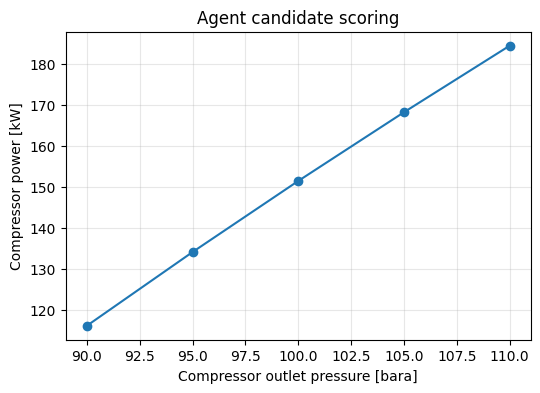

In [15]:
candidate_pressures = [90.0, 95.0, 100.0, 105.0, 110.0]
agent_trials = []

for pressure in candidate_pressures:
    result = as_json(
        auto.evaluate(
            java_map({"Export compressor.outletPressure": pressure}),
            "bara",
            java_list(["Export compressor.power"]),
            "kW",
            30,
            5.0e-3,
        )
    )
    power = result.get("readbacks", {}).get("Export compressor.power")
    agent_trials.append(
        {
            "candidate_outlet_pressure_bara": pressure,
            "feasible": result.get("feasible"),
            "power_kW": power,
            "rejected": bool(result.get("setpointsRejected")),
            "score": power if result.get("feasible") and power is not None else float("inf"),
        }
    )

agent_trials_df = pd.DataFrame(agent_trials)
best = agent_trials_df.loc[agent_trials_df["score"].idxmin()]

display(agent_trials_df)
print("Selected setpoint: %.1f bara at %.1f kW" % (best["candidate_outlet_pressure_bara"], best["power_kW"]))

plt.figure(figsize=(6, 4))
plt.plot(agent_trials_df["candidate_outlet_pressure_bara"], agent_trials_df["power_kW"], marker="o")
plt.xlabel("Compressor outlet pressure [bara]")
plt.ylabel("Compressor power [kW]")
plt.title("Agent candidate scoring")
plt.grid(True, alpha=0.3)
plt.show()

## Structured Run Feedback and Utilization Snapshot

A normal `run()` returns no Python value. The automation JSON methods expose whether the run succeeded, which unit failed, and what equipment is closest to a capacity limit. That makes the process usable as an observation/reward environment.

In [16]:
run_report = as_json(auto.runJson())
status_report = as_json(auto.getRunStatusJson())
utilization = as_json(auto.getUtilizationSnapshot())

utilization_rows = []
for unit in utilization.get("units", []):
    utilization_rows.append(
        {
            "unit": unit.get("name"),
            "type": unit.get("type"),
            "max_utilization_pct": unit.get("maxUtilizationPercent"),
            "limiting_constraint": unit.get("limitingConstraint"),
            "feasible": unit.get("feasible"),
            "hard_limit_exceeded": unit.get("hardLimitExceeded"),
            "power_kW": unit.get("power_kW"),
        }
    )

print("Run success:", run_report.get("success"), "failed unit:", run_report.get("failedUnitName"))
print("Previous status success:", status_report.get("success"))
print("Plant overloaded:", utilization.get("anyOverloaded"), "bottleneck:", utilization.get("bottleneck"))
display(pd.DataFrame(utilization_rows))

Run success: True failed unit: None
Previous status success: True
Plant overloaded: False bottleneck: {'name': 'Export compressor', 'utilization': 0.36869862957511496, 'utilizationPercent': 36.869862957511494, 'limitingConstraint': 'power'}


,unit,type,max_utilization_pct,limiting_constraint,feasible,hard_limit_exceeded,power_kW
0,Feed gas,Stream,0.000000,None,True,False,NaN
1,Gas cooler,Heater,0.000000,None,True,False,NaN
2,Inlet separator,Separator,0.000000,None,True,False,NaN
3,Export compressor,Compressor,36.869863,power,True,False,184.349315


## Multi-Area Addresses for Larger Plants

For full facilities, `ProcessModel` combines several `ProcessSystem` areas. Automation addresses become stable area-qualified strings such as `Cooling::Area cooler.outletTemperature`, which are easy for agents to log, replay, and compare across turns.

In [17]:
area_fluid = make_gas(temperature_c=25.0, pressure_bara=60.0)
area_feed = Stream("Area feed", area_fluid)
area_feed.setFlowRate(5000.0, "kg/hr")
area_cooler = Heater("Area cooler", area_feed)
area_cooler.setOutTemperature(273.15 + 15.0)

cooling_area = ProcessSystem()
for unit in [area_feed, area_cooler]:
    cooling_area.add(unit)
cooling_area.run()

plant = ProcessModel()
plant.add("Cooling", cooling_area)
plant.run()
plant_auto = plant.getAutomation()

area_temperature = plant_auto.getVariableValue("Cooling::Area cooler.outletStream.temperature", "C")
plant_auto.setVariableValue("Cooling::Area cooler.outletTemperature", 10.0, "C")
plant_auto.runIfDirty()
area_temperature_after = plant_auto.getVariableValue("Cooling::Area cooler.outletStream.temperature", "C")

print("Areas:", list(plant_auto.getAreaList()))
print("Area-qualified units:", list(plant_auto.getUnitList()))
print("Temperature before/after setpoint change: %.1f C -> %.1f C" % (area_temperature, area_temperature_after))
show_json(plant_auto.snapshot("Cooling::Area cooler"), max_chars=1000)

Areas: ['Cooling']
Area-qualified units: ['Cooling::Area feed', 'Cooling::Area cooler']
Temperature before/after setpoint change: 15.0 C -> 10.0 C
{
  "schemaVersion": "1.0",
  "scope": "Cooling::Area cooler",
  "dirty": false,
  "units": [
    {
      "name": "Cooling::Area cooler",
      "type": "Heater",
      "variables": {
        "temperature": {
          "value": NaN,
          "unit": "K",
          "type": "OUTPUT"
        },
        "pressure": {
          "value": NaN,
          "unit": "bara",
          "type": "OUTPUT"
        },
        "outletTemperature": {
          "value": 10.0,
          "unit": "C",
          "type": "INPUT"
        },
        "duty": {
          "value": -54587.714511280705,
          "unit": "W",
          "type": "OUTPUT"
        },
        "outletStream.temperature": {
          "value": 283.15,
          "unit": "K",
          "type": "OUTPUT"
        },
        "outletStream.pressure": {
          "value": 60.0,
          "unit": "bara",
   

## Why This Is Relevant for Agentic Use

The automation API gives an LLM or autonomous optimizer four practical handles:

- **Discovery:** `describe()`, `getUnitList()`, `getVariableList()`, and `getAdjustableParametersJson()` expose the process as data instead of Java object references.
- **Stable actions:** setpoints are strings such as `Export compressor.outletPressure`, so they can be logged, replayed, serialized, and corrected across tool calls.
- **Robust failure handling:** safe accessors and `evaluate(...)` return structured JSON diagnostics instead of forcing the agent to recover from opaque Java exceptions.
- **Closed-loop feedback:** `evaluate(...)`, `runJson()`, and `getUtilizationSnapshot()` provide objective values, feasibility flags, failed-unit context, and bottleneck observations for iterative decision making.

That combination is what makes a NeqSim process model usable as an agent environment: observe the JSON state, choose a string-addressed action, execute one gated trial, and score the result.